## Load Dataset

In [1]:
import os
import json
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict

In [2]:
import os

# Base project path
base_path = r"C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen"

# Dataset paths
healthy_path = os.path.join(base_path, "dataset", "dataset", "data", "healthy")
cva_path = os.path.join(base_path, "dataset", "dataset", "data", "neuro", "CVA")

print("Healthy path:", healthy_path)
print("CVA path:", cva_path)

print("Healthy exists:", os.path.exists(healthy_path))
print("CVA exists:", os.path.exists(cva_path))

Healthy path: C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset\dataset\data\healthy
CVA path: C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset\dataset\data\neuro\CVA
Healthy exists: True
CVA exists: True


In [3]:
import os

# =========================================
# SET PATH DATASET
# =========================================

base_path = r"C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen"

# Path dataset
healthy_path = os.path.join(base_path, "dataset", "dataset", "data", "healthy", "HS")
cva_path = os.path.join(base_path, "dataset", "dataset", "data", "neuro", "CVA")


# =========================================
# VERIFIKASI PATH
# =========================================

print("=== CHECK DATASET PATH ===")
print(f"CVA Path : {cva_path}")
print(f"Healthy Path  : {healthy_path}")

print(f"\nCVA exists : {os.path.exists(cva_path)}")
print(f"Healthy exists  : {os.path.exists(healthy_path)}")

# =========================================
# CEK FOLDER CVA
# =========================================

print("\n=== CVA FOLDERS ===")

if os.path.exists(cva_path):

    cva_folders = sorted([
        d for d in os.listdir(cva_path)
        if os.path.isdir(os.path.join(cva_path, d))
    ])

    print(f"Total CVA folders : {len(cva_folders)}")
    print("First few folders :")

    for folder in cva_folders[:5]:
        print("-", folder)

else:
    print("CVA folder tidak ditemukan!")

# =========================================
# CEK FOLDER HEALTHY
# =========================================

print("\n=== HEALTHY FOLDERS ===")

if os.path.exists(healthy_path):

    healthy_folders = sorted([
        d for d in os.listdir(healthy_path)
        if os.path.isdir(os.path.join(healthy_path, d))
    ])

    print(f"Total Healthy folders : {len(healthy_folders)}")
    print("First few folders :")

    for folder in healthy_folders[:5]:
        print("-", folder)

else:
    print("Healthy folder tidak ditemukan!")

=== CHECK DATASET PATH ===
CVA Path : C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset\dataset\data\neuro\CVA
Healthy Path  : C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset\dataset\data\healthy\HS

CVA exists : True
Healthy exists  : True

=== CVA FOLDERS ===
Total CVA folders : 49
First few folders :
- CVA_1
- CVA_10
- CVA_11
- CVA_12
- CVA_13

=== HEALTHY FOLDERS ===
Total Healthy folders : 73
First few folders :
- HS_1
- HS_10
- HS_11
- HS_12
- HS_13


## Extract Dataset

In [5]:
import os
import json
import pandas as pd
import numpy as np
import pickle

# =========================================
# 1. PATH DATASET (PATH PUNYA KAMU)
# =========================================

DATASET_DIR = r"C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset"

OUTPUT_PATH = r"C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset_cva_hs.pkl"

dataset_cva_hs = []

# =========================================
# 2. LOOP SEMUA FILE
# =========================================

for root, dirs, files in os.walk(DATASET_DIR):

    for filename in files:

        # Ambil hanya metadata json
        if not filename.endswith("_meta.json"):
            continue

        base_name = filename.replace("_meta.json", "")

        json_path = os.path.join(root, filename)

        # =========================================
        # 3. LOAD JSON
        # =========================================

        try:
            with open(json_path, 'r') as f:
                meta = json.load(f)

        except Exception as e:
            print(f"Gagal load JSON: {json_path}")
            continue

        pathology = meta.get("pathologyKey")

        # Hanya CVA dan HS
        if pathology not in ["CVA", "HS"]:
            continue

        # =========================================
        # 4. AMBIL METADATA
        # =========================================

        age = meta.get("age")
        gender = meta.get("gender")
        height = meta.get("height")
        weight = meta.get("weight")
        bmi = meta.get("BMI")
        laterality = meta.get("laterality")

        deficit_side = meta.get("clinicalDeficitSide")

        if deficit_side is None:
            deficit_side = "None"

        fma_score = meta.get("evaluationScoreValue")

        # Default score HS
        if pathology == "HS" and fma_score is None:
            fma_score = 34.0

        uturn_bounds = meta.get("uturnBoundaries", [])

        # =========================================
        # 5. LOAD SENSOR DATA
        # =========================================

        txt_filename = f"{base_name}_processed_data.txt"

        txt_path = os.path.join(root, txt_filename)

        if not os.path.exists(txt_path):
            print(f"TXT tidak ditemukan: {txt_path}")
            continue

        try:
            sensor_df = pd.read_csv(txt_path, sep=r'\s+')

        except Exception as e:
            print(f"Gagal load TXT: {txt_path}")
            continue

        # =========================================
        # 6. AMBIL SENSOR COLUMNS
        # =========================================

        try:

            lb_data = sensor_df[
                [
                    'LF_FreeAcc_X',
                    'LF_FreeAcc_Y',
                    'LF_FreeAcc_Z',
                    'LF_Gyr_X',
                    'LF_Gyr_Y',
                    'LF_Gyr_Z',
                    'RF_FreeAcc_X',
                    'RF_FreeAcc_Y',
                    'RF_FreeAcc_Z',
                    'RF_Gyr_X',
                    'RF_Gyr_Y',
                    'RF_Gyr_Z'
                ]
            ].copy()

        except KeyError:
            print(f"Kolom sensor tidak lengkap: {txt_path}")
            continue

        # =========================================
        # 7. TAMBAH FLAG UTURN
        # =========================================

        lb_data['Uturn_Flag'] = 0

        if uturn_bounds and len(uturn_bounds) == 2:

            u_start = int(max(0, uturn_bounds[0]))
            u_end = int(min(len(lb_data), uturn_bounds[1]))

            lb_data.iloc[
                u_start:u_end,
                lb_data.columns.get_loc('Uturn_Flag')
            ] = 1

        # =========================================
        # 8. SUSUN DATASET
        # =========================================

        dataset_v2 = {

            "subject_id": base_name.rsplit('_', 1)[0],

            "pathology": pathology,

            "sensor_matrix": lb_data.values.astype(np.float32),

            "fma_score": float(fma_score),

            "meta_features": {
                "age": age,
                "gender": gender,
                "height": height,
                "weight": weight,
                "BMI": bmi,
                "laterality": laterality,
                "deficit_side": deficit_side
            }
        }

        dataset_cva_hs.append(dataset_v2)

# =========================================
# 9. SAVE DATASET
# =========================================

with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(dataset_cva_hs, f)

# =========================================
# 10. SUMMARY
# =========================================

print("\n====================================")
print("Ekstraksi selesai!")
print(f"Total trial: {len(dataset_cva_hs)}")
print(f"Dataset disimpan di:")
print(OUTPUT_PATH)
print("====================================")


Ekstraksi selesai!
Total trial: 488
Dataset disimpan di:
C:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset_cva_hs.pkl


## Preprocessing

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

WINDOW_SIZE = 400
STEP_SIZE = 200

X_sensor_list = []
y_list = []
group_list = []
meta_records = []

for trial in dataset_cva_hs: 
    sensor_matrix = trial["sensor_matrix"]
    subject_id = trial["subject_id"]
    fma_score = trial["fma_score"]
    meta = trial["meta_features"]

    sensor_data = sensor_matrix[:, :9]
    uturn_flag = sensor_matrix[:, 9].reshape(-1, 1)

    scaler = StandardScaler()
    sensor_scaled = scaler.fit_transform(sensor_data)

    matrix_processed = np.hstack((sensor_scaled, uturn_flag))

    num_rows = matrix_processed.shape[0]

    for start in range(0, num_rows - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE
        window = matrix_processed[start:end, :]

        X_sensor_list.append(window)
        y_list.append(fma_score)
        group_list.append(subject_id)
        meta_records.append(meta)

X_sensor = np.array(X_sensor_list)
y = np.array(y_list)
groups = np.array(group_list)

# metadata
meta_df = pd.DataFrame(meta_records)

numeric_features = ['age', 'height', 'weight', 'BMI']
categorical_features = ['gender', 'laterality', 'deficit_side']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
])

X_meta = preprocessor.fit_transform(meta_df)

print(X_sensor.shape, X_meta.shape, y.shape)

(5712, 400, 10) (5712, 11) (5712,)


In [7]:
from sklearn.model_selection import train_test_split

# 1. BUAT DATAFRAME META PER WINDOW
subject_meta_df = pd.DataFrame(meta_records).copy()
subject_meta_df['subject_id'] = groups

# 2. AMBIL 1 BARIS PER SUBJECT
unique_subjects = subject_meta_df.drop_duplicates(subset=['subject_id']).copy()

# 3. BUAT LABEL STRATIFIKASI
# HS jika deficit_side == "None"
unique_subjects['is_HS'] = (unique_subjects['deficit_side'] == 'None')

# HANDLE missing gender (biar ga error)
unique_subjects['gender'] = unique_subjects['gender'].fillna('Unknown')

# Gabungan label
unique_subjects['stratify_label'] = (
    unique_subjects['is_HS'].astype(str) + "_" +
    unique_subjects['gender'].astype(str)
)

# CEK DISTRIBUSI
print("\nDistribusi Stratifikasi:")
print(unique_subjects['stratify_label'].value_counts())

# 4. SPLIT SUBJECT (80-10-10)
X_subj = unique_subjects['subject_id'].values
y_subj_stratify = unique_subjects['stratify_label'].values

# Test 10%
subj_train_val, subj_test = train_test_split(
    X_subj,
    test_size=0.10,
    random_state=42,
    stratify=y_subj_stratify
)

# Ambil label stratifikasi untuk train+val
mask_train_val = unique_subjects['subject_id'].isin(subj_train_val)
y_subj_stratify_train_val = unique_subjects.loc[mask_train_val, 'stratify_label'].values

# Validation 10%
subj_train, subj_val = train_test_split(
    subj_train_val,
    test_size=0.1111,  # ≈10% dari total
    random_state=42,
    stratify=y_subj_stratify_train_val
)

# 5. MAPPING KE WINDOW
train_idx = np.isin(groups, subj_train)
val_idx   = np.isin(groups, subj_val)
test_idx  = np.isin(groups, subj_test)

# Split sensor
X_sensor_train = X_sensor[train_idx]
X_sensor_val   = X_sensor[val_idx]
X_sensor_test  = X_sensor[test_idx]

# Split metadata
X_meta_train = X_meta[train_idx]
X_meta_val   = X_meta[val_idx]
X_meta_test  = X_meta[test_idx]

# Split label
y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

# 6. VERIFIKASI
print("\nSplit done")

print("\nDimensi Data:")
print(f"Train : {X_sensor_train.shape}, {X_meta_train.shape}, {y_train.shape}")
print(f"Val   : {X_sensor_val.shape}, {X_meta_val.shape}, {y_val.shape}")
print(f"Test  : {X_sensor_test.shape}, {X_meta_test.shape}, {y_test.shape}")

# 7. CEK SUBJECT OVERLAP (HARUS 0!)
train_subj = set(subj_train)
val_subj   = set(subj_val)
test_subj  = set(subj_test)

print("\nCek overlap subject:")
print("Train ∩ Val  :", len(train_subj & val_subj))
print("Train ∩ Test :", len(train_subj & test_subj))
print("Val ∩ Test   :", len(val_subj & test_subj))


Distribusi Stratifikasi:
stratify_label
True_M     41
False_M    37
True_F     32
False_F    12
Name: count, dtype: int64

Split done

Dimensi Data:
Train : (4375, 400, 10), (4375, 11), (4375,)
Val   : (655, 400, 10), (655, 11), (655,)
Test  : (682, 400, 10), (682, 11), (682,)

Cek overlap subject:
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0


## Arsitektur Training (Ablation Study)
- CNN + BIGRU + Attention
- Bitcn - Bigru - cross Attention


###  CNN + Bigru + Attention 
(Experiment - Raisa)

In [9]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [10]:
from tensorflow import keras

# SENSOR BRANCH
input_sensor = Input(shape=(400, 10))

x = Conv1D(128, 5, activation='relu', padding='same')(input_sensor)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(256, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

# BiGRU
x = Bidirectional(GRU(192, return_sequences=True))(x)
x = Bidirectional(GRU(128, return_sequences=True))(x)

# ATTENTION
x = Dense(128, activation='relu')(x)
attention = Dense(1, activation='tanh')(x)   # (batch, time, 1)
attention = Softmax(axis=1)(attention)       # normalize across time

x = Multiply()([x, attention])
x = Lambda(lambda z: tf.reduce_sum(z, axis=1))(x)

# META BRANCH
input_meta = Input(shape=(X_meta.shape[1],))
m = Dense(128, activation='relu')(input_meta)
m = Dense(64, activation='relu')(m)

# CONCAT
combined = concatenate([x, m])

z = Dense(128, activation='relu')(combined)
z = Dropout(0.1)(z)
output = Dense(1)(z)  # regression FMA

model = Model(inputs=[input_sensor, input_meta], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 400, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 400, 128)  │      6,528 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 200, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 200, 256)  │     98,560 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 256)  │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 100, 256)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 100, 384)  │    518,400 │ max_pooling1d_3[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 100, 256)  │    394,752 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 100, 128)  │     32,896 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 100, 1)    │        129 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 100, 1)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 100, 128)  │          0 │ dense_2[0][0],    │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      1,536 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ lambda_1[0][0],   │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_6[0][0]   

 Total params: 1,087,426 (4.15 MB)

 Trainable params: 1,086,658 (4.15 MB)

 Non-trainable params: 768 (3.00 KB)

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Simpan model terbaik berdasarkan validation loss
checkpoint = ModelCheckpoint(
    "best_model.keras",          # nama file
    monitor="val_loss",       # patokan
    save_best_only=True,      # hanya simpan yg terbaik
    mode="min",               # karena loss ingin kecil
    verbose=1
)

# Stop kalau tidak membaik
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,              # berhenti kalau 5 epoch ga membaik
    restore_best_weights=True
)

history = model.fit(
    [X_sensor_train, X_meta_train],
    y_train,
    validation_data=([X_sensor_val, X_meta_val], y_val),
    epochs=100,
    batch_size=64,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 2.0709 - mae: 2.0709
Epoch 1: val_loss improved from None to 3.94428, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 412ms/step - loss: 2.0923 - mae: 2.0923 - val_loss: 3.9443 - val_mae: 3.9443
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 2.1075 - mae: 2.1075
Epoch 2: val_loss did not improve from 3.94428
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 405ms/step - loss: 2.0667 - mae: 2.0667 - val_loss: 4.0795 - val_mae: 4.0795
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - loss: 1.9888 - mae: 1.9888
Epoch 3: val_loss did not improve from 3.94428
69/69 ━━━━━━━━━━━━━━━━━━━━ 34s 488ms/step - loss: 2.0262 - mae: 2.0262 - val_loss: 4.2214 - val_mae: 4.2214
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 1.9772 - mae: 1.9772
Epoch 4: val_loss improved from 3.94428 to 3.90194, saving model to best_model.keras

Epoch 4: finished saving model to 

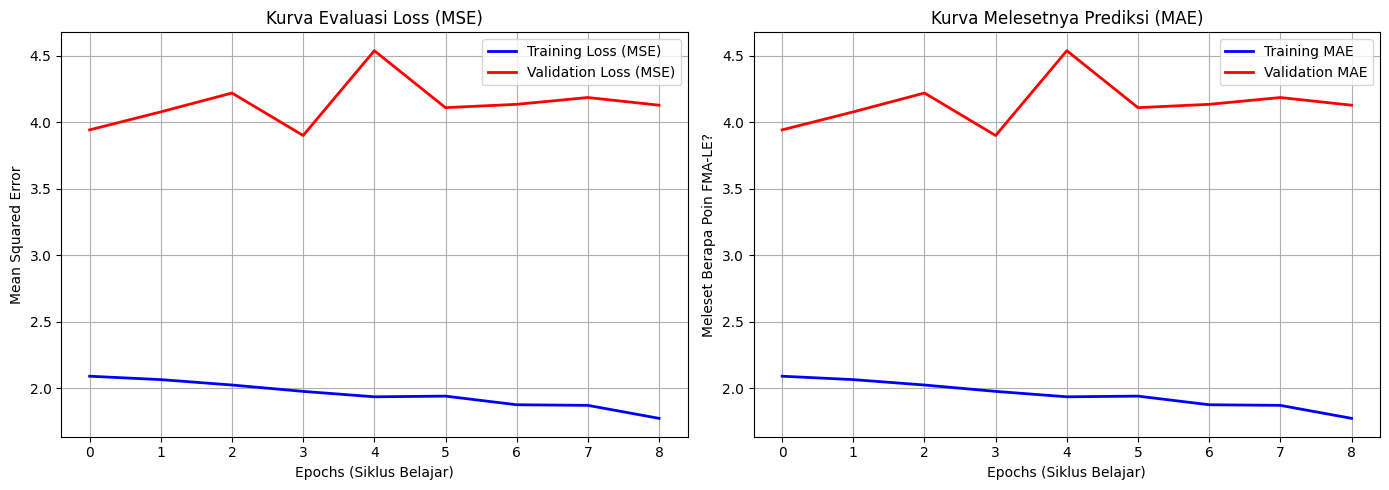


Pelatihan Selesai! Model terbaik telah disimpan sebagai 'model_gait_cva_terbaik.h5'


In [17]:
# 3. VISUALISASI KURVA PEMBELAJARAN
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Mean Squared Error (MSE) - Kurva Loss Utama
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red', linewidth=2)
plt.title('Kurva Evaluasi Loss (MSE)')
plt.xlabel('Epochs (Siklus Belajar)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Plot 2: Mean Absolute Error (MAE) - Selisih Poin Keparahan Aktual
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', color='blue', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', color='red', linewidth=2)
plt.title('Kurva Melesetnya Prediksi (MAE)')
plt.xlabel('Epochs (Siklus Belajar)')
plt.ylabel('Meleset Berapa Poin FMA-LE?')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nPelatihan Selesai! Model terbaik telah disimpan sebagai 'model_gait_cva_terbaik.h5'")

Langkah 6: Memulai Evaluasi Final pada Data Testing (10% Data Tersembunyi)...
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step

[HASIL UJIAN FINAL (TEST SET)]
Mean Squared Error (MSE)       : 64.1527
Root Mean Squared Error (RMSE) : 8.0095 Poin FMA-LE
Mean Absolute Error (MAE)      : 3.2990 Poin FMA-LE
R-Squared (R2)                 : -1.7352

-> Kinerja cukup, namun model mungkin kesulitan memprediksi beberapa variasi data yang ekstrem.


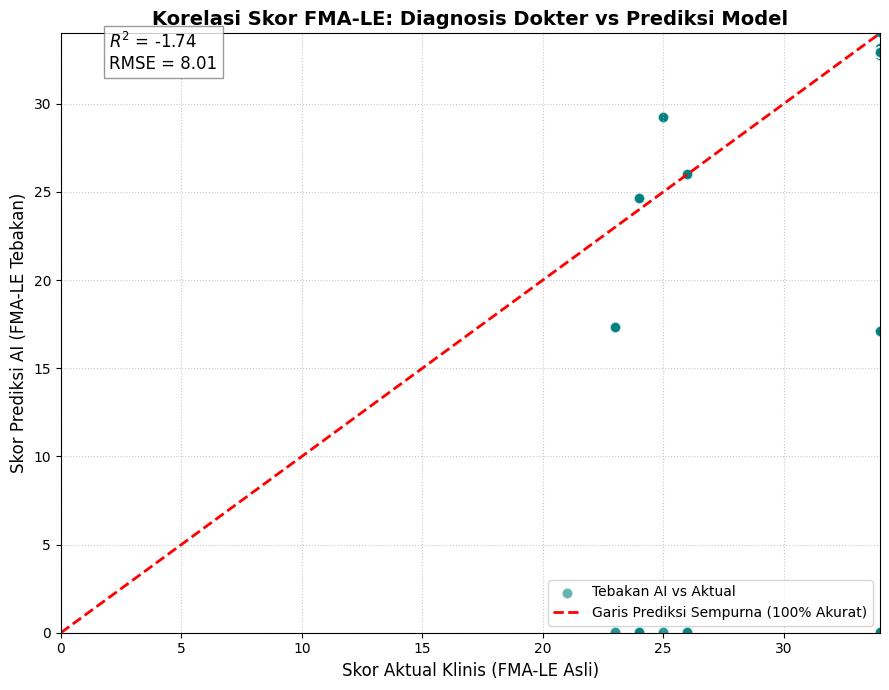


Contoh Komparasi Langsung (10 Jendela Acak Pertama):
Data ke-01 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-02 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-03 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-04 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-05 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-06 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-07 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-08 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-09 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)
Data ke-10 | Aktual: 34.0 | Prediksi AI: 33.2  (Meleset: 0.8 poin)


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("Langkah 6: Memulai Evaluasi Final pada Data Testing (10% Data Tersembunyi)...")

# 1. Menyuruh AI menebak skor pasien di data Test
y_pred = model.predict([X_sensor_test, X_meta_test]).flatten()

# 2. Menghitung semua Metrik Evaluasi
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("\n=========================================")
print(f"[HASIL UJIAN FINAL (TEST SET)]")
print(f"Mean Squared Error (MSE)       : {test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {test_rmse:.4f} Poin FMA-LE")
print(f"Mean Absolute Error (MAE)      : {test_mae:.4f} Poin FMA-LE")
print(f"R-Squared (R2)                 : {test_r2:.4f}")
print("=========================================\n")

if test_r2 > 0.7:
    print("-> Sangat Hebat! Model memiliki korelasi prediktif yang sangat kuat.")
elif test_r2 > 0.5:
    print("-> Bagus! Terdapat korelasi yang positif dan kuat antara sensor dan tingkat keparahan stroke.")
else:
    print("-> Kinerja cukup, namun model mungkin kesulitan memprediksi beberapa variasi data yang ekstrem.")

# 3. Visualisasi Scatter Plot (Tebakan AI vs Diagnosis Asli)
plt.figure(figsize=(9, 7))
# Plot titik-titik tebakan AI
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='white', s=60, label='Tebakan AI vs Aktual')

# Buat garis referensi diagonal (Jika tebakan 100% akurat, titik-titik akan berada di garis ini)
plt.plot([0, 34], [0, 34], 'r--', linewidth=2, label='Garis Prediksi Sempurna (100% Akurat)')

# Menambahkan anotasi metrik ke dalam grafik
plt.text(2, 32, f'$R^2$ = {test_r2:.2f}\nRMSE = {test_rmse:.2f}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('Korelasi Skor FMA-LE: Diagnosis Dokter vs Prediksi Model', fontsize=14, fontweight='bold')
plt.xlabel('Skor Aktual Klinis (FMA-LE Asli)', fontsize=12)
plt.ylabel('Skor Prediksi AI (FMA-LE Tebakan)', fontsize=12)
plt.xlim(0, 34)
plt.ylim(0, 34)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Tampilkan perbandingan langsung untuk 10 sampel acak
print("\nContoh Komparasi Langsung (10 Jendela Acak Pertama):")
for i in range(10):
    selisih = abs(y_test[i] - y_pred[i])
    print(f"Data ke-{i+1:02d} | Aktual: {y_test[i]:.1f} | Prediksi AI: {y_pred[i]:.1f}  (Meleset: {selisih:.1f} poin)")

###  BiTCN + Bigru + Attention 
(Experiment - Zela)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================
# 1. TCN BLOCK
# =========================

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.dropout = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) \
            if in_channels != out_channels else None

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = F.relu(self.bn1(out))
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = F.relu(self.bn2(out))
        out = self.dropout(out)

        residual = x if self.downsample is None else self.downsample(x)

        return F.relu(out + residual)


# =========================
# 2. BiTCN
# =========================

class BiTCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, kernel_size=3, dropout=0.2):
        super().__init__()

        self.forward_tcn = nn.Sequential(
            TemporalBlock(input_dim, hidden_dim, kernel_size, dilation=1, dropout=dropout),
            TemporalBlock(hidden_dim, hidden_dim, kernel_size, dilation=2, dropout=dropout),
            TemporalBlock(hidden_dim, hidden_dim, kernel_size, dilation=4, dropout=dropout)
        )

        self.backward_tcn = nn.Sequential(
            TemporalBlock(input_dim, hidden_dim, kernel_size, dilation=1, dropout=dropout),
            TemporalBlock(hidden_dim, hidden_dim, kernel_size, dilation=2, dropout=dropout),
            TemporalBlock(hidden_dim, hidden_dim, kernel_size, dilation=4, dropout=dropout)
        )

    def forward(self, x):
        # x: (batch, time, features)
        x_fwd = x.permute(0, 2, 1)

        x_bwd = torch.flip(x, dims=[1])
        x_bwd = x_bwd.permute(0, 2, 1)

        out_fwd = self.forward_tcn(x_fwd)
        out_bwd = self.backward_tcn(x_bwd)

        out_bwd = torch.flip(out_bwd, dims=[2])

        out = torch.cat([out_fwd, out_bwd], dim=1)

        # output: (batch, time, hidden*2)
        out = out.permute(0, 2, 1)

        return out


# =========================
# 3. CROSS ATTENTION
# =========================

class CrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4, dropout=0.2):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value):
        attn_output, attn_weights = self.attention(
            query=query,
            key=key_value,
            value=key_value
        )

        out = self.norm(query + self.dropout(attn_output))

        return out, attn_weights


# =========================
# 4. FULL MODEL
# =========================

class BiTCN_BiGRU_CrossAttention(nn.Module):
    def __init__(
        self,
        input_dim=13,
        tcn_hidden=64,
        gru_hidden=64,
        num_heads=4,
        dropout=0.2,
        output_dim=1
    ):
        super().__init__()

        self.bitcn = BiTCN(
            input_dim=input_dim,
            hidden_dim=tcn_hidden,
            kernel_size=3,
            dropout=dropout
        )

        self.bigru = nn.GRU(
            input_size=input_dim,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        # BiTCN output = tcn_hidden * 2
        # BiGRU output = gru_hidden * 2
        self.tcn_proj = nn.Linear(tcn_hidden * 2, 128)
        self.gru_proj = nn.Linear(gru_hidden * 2, 128)

        self.cross_attn_tcn_to_gru = CrossAttention(
            embed_dim=128,
            num_heads=num_heads,
            dropout=dropout
        )

        self.cross_attn_gru_to_tcn = CrossAttention(
            embed_dim=128,
            num_heads=num_heads,
            dropout=dropout
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        # x: (batch, time, features)

        tcn_out = self.bitcn(x)
        gru_out, _ = self.bigru(x)

        tcn_out = self.tcn_proj(tcn_out)
        gru_out = self.gru_proj(gru_out)

        # Cross Attention
        tcn_attended, _ = self.cross_attn_tcn_to_gru(
            query=tcn_out,
            key_value=gru_out
        )

        gru_attended, _ = self.cross_attn_gru_to_tcn(
            query=gru_out,
            key_value=tcn_out
        )

        # Pooling
        tcn_pool = self.pool(tcn_attended.permute(0, 2, 1)).squeeze(-1)
        gru_pool = self.pool(gru_attended.permute(0, 2, 1)).squeeze(-1)

        fused = torch.cat([tcn_pool, gru_pool], dim=1)

        output = self.fc(fused)

        return output

In [1]:
from torchinfo import summary

# ====================================
# INIT MODEL
# ====================================

model = BiTCN_BiGRU_CrossAttention(
    input_dim=13,
    output_dim=1
)

# ====================================
# MODEL SUMMARY
# ====================================

summary(
    model,
    input_size=(8, 400, 13)
)

NameError: name 'BiTCN_BiGRU_CrossAttention' is not defined

In [5]:
# =========================================
# PREPROCESSING: WINDOWING & SCALING
# =========================================

WINDOW_SIZE = 400
STEP_SIZE = 200

X_sensor_list = []
y_list = []
group_list = []
meta_records = []

for trial in dataset_cva_hs:
    sensor_matrix = trial["sensor_matrix"]
    subject_id = trial["subject_id"]
    fma_score = trial["fma_score"]
    meta = trial["meta_features"]
    
    # Extract sensor data (first 12 columns: acc + gyro)
    sensor_data = sensor_matrix[:, :12]
    uturn_flag = sensor_matrix[:, 12].reshape(-1, 1)
    
    # Normalize sensor data
    scaler = StandardScaler()
    sensor_scaled = scaler.fit_transform(sensor_data)
    
    matrix_processed = np.hstack((sensor_scaled, uturn_flag))
    
    # Create windows
    num_rows = matrix_processed.shape[0]
    for start in range(0, num_rows - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE
        window = matrix_processed[start:end, :]
        
        X_sensor_list.append(window)
        y_list.append(fma_score)
        group_list.append(subject_id)
        meta_records.append(meta)

X_sensor = np.array(X_sensor_list)
y = np.array(y_list)
groups = np.array(group_list)
meta_df = pd.DataFrame(meta_records)

print(f"\nPreprocessing Results:")
print(f"X_sensor shape: {X_sensor.shape}")
print(f"y shape: {y.shape}")
print(f"Number of windows: {len(X_sensor_list)}")

# Normalize metadata
numeric_features = ['age', 'height', 'weight', 'BMI']
categorical_features = ['gender', 'laterality', 'deficit_side']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
])

X_meta = preprocessor.fit_transform(meta_df)
print(f"X_meta shape: {X_meta.shape}")



Preprocessing Results:
X_sensor shape: (5712, 400, 13)
y shape: (5712,)
Number of windows: 5712
X_meta shape: (5712, 11)


In [6]:
# =========================================
# TRAIN-VAL-TEST SPLIT (Subject-level)
# =========================================

subject_meta_df = pd.DataFrame(meta_records).copy()
subject_meta_df['subject_id'] = groups

unique_subjects = subject_meta_df.drop_duplicates(subset=['subject_id']).copy()
unique_subjects['is_HS'] = (unique_subjects['deficit_side'] == 'None')
unique_subjects['gender'] = unique_subjects['gender'].fillna('Unknown')
unique_subjects['stratify_label'] = (
    unique_subjects['is_HS'].astype(str) + "_" + 
    unique_subjects['gender'].astype(str)
)

print("\nStratification Distribution:")
print(unique_subjects['stratify_label'].value_counts())

X_subj = unique_subjects['subject_id'].values
y_subj_stratify = unique_subjects['stratify_label'].values

# Split: 80% train+val, 10% test
subj_train_val, subj_test = train_test_split(
    X_subj,
    test_size=0.10,
    random_state=42,
    stratify=y_subj_stratify
)

mask_train_val = unique_subjects['subject_id'].isin(subj_train_val)
y_subj_stratify_train_val = unique_subjects.loc[mask_train_val, 'stratify_label'].values

# Split: 80% train, 20% val (from train+val)
subj_train, subj_val = train_test_split(
    subj_train_val,
    test_size=0.1111,  # ~10% of total
    random_state=42,
    stratify=y_subj_stratify_train_val
)

# Map to window indices
train_idx = np.isin(groups, subj_train)
val_idx   = np.isin(groups, subj_val)
test_idx  = np.isin(groups, subj_test)

X_sensor_train = X_sensor[train_idx].astype(np.float32)
X_sensor_val   = X_sensor[val_idx].astype(np.float32)
X_sensor_test  = X_sensor[test_idx].astype(np.float32)

X_meta_train = X_meta[train_idx].astype(np.float32)
X_meta_val   = X_meta[val_idx].astype(np.float32)
X_meta_test  = X_meta[test_idx].astype(np.float32)

y_train = y[train_idx].astype(np.float32)
y_val   = y[val_idx].astype(np.float32)
y_test  = y[test_idx].astype(np.float32)

print("\nTrain-Val-Test Split:")
print(f"Train: sensor {X_sensor_train.shape}, meta {X_meta_train.shape}, label {y_train.shape}")
print(f"Val:   sensor {X_sensor_val.shape}, meta {X_meta_val.shape}, label {y_val.shape}")
print(f"Test:  sensor {X_sensor_test.shape}, meta {X_meta_test.shape}, label {y_test.shape}")

train_subj = set(subj_train)
val_subj   = set(subj_val)
test_subj  = set(subj_test)

print("\nSubject Overlap Check:")
print(f"Train ∩ Val: {len(train_subj & val_subj)}")
print(f"Train ∩ Test: {len(train_subj & test_subj)}")
print(f"Val ∩ Test: {len(val_subj & test_subj)}")

# Convert to torch tensors
X_sensor_train_t = torch.from_numpy(X_sensor_train)
X_sensor_val_t   = torch.from_numpy(X_sensor_val)
X_sensor_test_t  = torch.from_numpy(X_sensor_test)

X_meta_train_t = torch.from_numpy(X_meta_train)
X_meta_val_t   = torch.from_numpy(X_meta_val)
X_meta_test_t  = torch.from_numpy(X_meta_test)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

print("\nTorch Tensor Shapes:")
print(f"Train: {X_sensor_train_t.shape}, {X_meta_train_t.shape}")
print(f"Val:   {X_sensor_val_t.shape}, {X_meta_val_t.shape}")
print(f"Test:  {X_sensor_test_t.shape}, {X_meta_test_t.shape}")



Stratification Distribution:
stratify_label
True_M     41
False_M    37
True_F     32
False_F    12
Name: count, dtype: int64

Train-Val-Test Split:
Train: sensor (4375, 400, 13), meta (4375, 11), label (4375,)
Val:   sensor (655, 400, 13), meta (655, 11), label (655,)
Test:  sensor (682, 400, 13), meta (682, 11), label (682,)

Subject Overlap Check:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0

Torch Tensor Shapes:
Train: torch.Size([4375, 400, 13]), torch.Size([4375, 11])
Val:   torch.Size([655, 400, 13]), torch.Size([655, 11])
Test:  torch.Size([682, 400, 13]), torch.Size([682, 11])


In [1]:
from torch.utils.data import TensorDataset, DataLoader

# =========================================
# MODEL INITIALIZATION
# =========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = BiTCN_BiGRU_CrossAttention(
    input_dim=13,           # 12 sensor features + 1 uturn flag
    tcn_hidden=64,
    gru_hidden=64,
    num_heads=4,
    dropout=0.2,
    output_dim=1
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Parameters: {total_params:,}")

# =========================================
# CREATE DATA LOADERS
# =========================================

train_dataset = TensorDataset(X_sensor_train_t, X_meta_train_t, y_train_t)
val_dataset = TensorDataset(X_sensor_val_t, X_meta_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nDataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# =========================================
# TRAINING SETUP
# =========================================

criterion = torch.nn.L1Loss()  # MAE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# =========================================
# TRAINING LOOP
# =========================================

import matplotlib.pyplot as plt
from tqdm import tqdm

NUM_EPOCHS = 100
PATIENCE = 5
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

print("\n" + "="*60)
print("TRAINING BITCN-BIGRU-CROSSATTENTION MODEL")
print("="*60 + "\n")

for epoch in range(NUM_EPOCHS):
    # ========= TRAIN =========
    model.train()
    train_loss = 0.0
    
    for sensor_batch, meta_batch, label_batch in train_loader:
        sensor_batch = sensor_batch.to(device)
        meta_batch = meta_batch.to(device)
        label_batch = label_batch.to(device)
        
        optimizer.zero_grad()
        
        output = model(sensor_batch)
        loss = criterion(output.squeeze(), label_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # ========= VALIDATION =========
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for sensor_batch, meta_batch, label_batch in val_loader:
            sensor_batch = sensor_batch.to(device)
            meta_batch = meta_batch.to(device)
            label_batch = label_batch.to(device)
            
            output = model(sensor_batch)
            loss = criterion(output.squeeze(), label_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # ========= EARLY STOPPING & LR SCHEDULING =========
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_bitcn_bigru_model.pt")
    else:
        patience_counter += 1
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Patience: {patience_counter}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)

# Load best model
model.load_state_dict(torch.load("best_bitcn_bigru_model.pt"))
print("Loaded best model checkpoint")


NameError: name 'torch' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)
plt.title('BiTCN-BiGRU-CrossAttention: Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss (FMA-LE Points)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Zoom on last 20 epochs
plt.subplot(1, 2, 2)
plt.plot(train_losses[-20:], label='Training Loss (Last 20 Epochs)', color='blue', linewidth=2)
plt.plot(val_losses[-20:], label='Validation Loss (Last 20 Epochs)', color='red', linewidth=2)
plt.title('Loss Curves (Zoomed)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch (Last 20)')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"Initial Train Loss: {train_losses[0]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total Epochs Trained: {len(train_losses)}")


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================
# TEST SET EVALUATION
# =========================================

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60 + "\n")

model.eval()
test_loader = DataLoader(
    TensorDataset(X_sensor_test_t, X_meta_test_t, y_test_t),
    batch_size=32,
    shuffle=False
)

y_pred_list = []

with torch.no_grad():
    for sensor_batch, meta_batch, label_batch in test_loader:
        sensor_batch = sensor_batch.to(device)
        meta_batch = meta_batch.to(device)
        
        output = model(sensor_batch)
        y_pred_list.append(output.cpu().numpy().squeeze())

y_pred = np.concatenate(y_pred_list, axis=0)

# Convert to numpy for sklearn metrics
y_test_np = y_test.numpy()

# Calculate metrics
test_mse = mean_squared_error(y_test_np, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_np, y_pred)
test_r2 = r2_score(y_test_np, y_pred)

print(f"Mean Squared Error (MSE)       : {test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {test_rmse:.4f} FMA-LE Points")
print(f"Mean Absolute Error (MAE)      : {test_mae:.4f} FMA-LE Points")
print(f"R² Score                       : {test_r2:.4f}")

if test_r2 > 0.7:
    print("\n✓ Excellent! Model has very strong predictive correlation.")
elif test_r2 > 0.5:
    print("\n✓ Good! Strong positive correlation between sensors and FMA-LE severity.")
else:
    print("\n~ Fair performance. Model may struggle with extreme variations.")

# Error distribution
errors = np.abs(y_test_np - y_pred)
print(f"\nError Distribution:")
for threshold in [1, 2, 3, 5]:
    acc = np.mean(errors <= threshold) * 100
    print(f"  Error ≤ {threshold} point(s): {acc:.1f}%")

# =========================================
# VISUALIZATION: Predictions vs Actuals
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(y_test_np, y_pred, alpha=0.6, color='teal', edgecolor='white', s=50)
ax.plot([y_test_np.min(), y_test_np.max()], 
        [y_test_np.min(), y_test_np.max()], 
        'r--', linewidth=2, label='Perfect Prediction')
ax.text(0.05, 0.95, f'R² = {test_r2:.4f}\nRMSE = {test_rmse:.2f}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_xlabel('Actual FMA-LE Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted FMA-LE Score', fontsize=11, fontweight='bold')
ax.set_title('BiTCN-BiGRU-CrossAttention: Predictions vs Actuals', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Residual plot
ax = axes[1]
ax.scatter(y_pred, errors, alpha=0.6, color='crimson', edgecolor='white', s=50)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=test_mae, color='green', linestyle='--', linewidth=2, label=f'Mean Error ({test_mae:.2f})')
ax.set_xlabel('Predicted FMA-LE Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Absolute Error (FMA-LE Points)', fontsize=11, fontweight='bold')
ax.set_title('Residual Analysis', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================
# SAMPLE PREDICTIONS
# =========================================

print("\n" + "="*60)
print("Sample Predictions (First 15):")
print("="*60)
print(f"{'Idx':<5} {'Actual':<10} {'Predicted':<12} {'Error':<10}")
print("-" * 45)
for i in range(min(15, len(y_test_np))):
    error = abs(y_test_np[i] - y_pred[i])
    print(f"{i+1:<5} {y_test_np[i]:<10.2f} {y_pred[i]:<12.2f} {error:<10.2f}")

print("\n" + "="*60)
print("EVALUATION COMPLETE ✓")
print("="*60)


## Model Export & Deployment

In [ ]:
# =========================================
# SAVE MODEL
# =========================================

model_save_path = os.path.join(base_path, "bitcn_bigru_crossattention_model.pt")
torch.save(model.state_dict(), model_save_path)

print(f"\n✓ Model saved to: {model_save_path}")

# =========================================
# EXPORT TO ONNX (for deployment)
# =========================================

print("\nExporting model to ONNX format...")

dummy_sensor = torch.randn(1, 400, 13).to(device)
dummy_meta = torch.randn(1, X_meta.shape[1]).to(device)

onnx_path = os.path.join(base_path, "bitcn_bigru_crossattention_model.onnx")

try:
    torch.onnx.export(
        model,
        (dummy_sensor,),  # Only sensor input for ONNX export
        onnx_path,
        input_names=['sensor_input'],
        output_names=['fma_prediction'],
        opset_version=14,
        do_constant_folding=True,
    )
    print(f"✓ ONNX model exported to: {onnx_path}")
except Exception as e:
    print(f"! ONNX export failed: {e}")

# =========================================
# CREATE MODEL CONFIG
# =========================================

config = {
    "model_type": "BiTCN_BiGRU_CrossAttention",
    "input_features": 13,
    "sensor_window_size": 400,
    "metadata_features": X_meta.shape[1],
    "tcn_hidden": 64,
    "gru_hidden": 64,
    "num_heads": 4,
    "dropout": 0.2,
    "output_range": [0, 66],
    "test_metrics": {
        "R2_score": float(test_r2),
        "RMSE": float(test_rmse),
        "MAE": float(test_mae),
    },
    "training_info": {
        "epochs_trained": len(train_losses),
        "final_train_loss": float(train_losses[-1]),
        "best_val_loss": float(best_val_loss),
    }
}

config_path = os.path.join(base_path, "bitcn_bigru_config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Model config saved to: {config_path}")

print("\n" + "="*60)
print("DEPLOYMENT READY")
print("="*60)
print(f"\nArtifacts:")
print(f"  1. PyTorch Model: {model_save_path}")
print(f"  2. ONNX Model: {onnx_path}")
print(f"  3. Config: {config_path}")
print(f"\nModel Performance Summary:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  MAE: {test_mae:.4f} FMA-LE points")
print(f"  RMSE: {test_rmse:.4f} FMA-LE points")
